## IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install tensorflow
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, max_error

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, max_error
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import max_error
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam

from math import pi
import warnings
warnings.filterwarnings("ignore")


C:\Users\SOMUJIT\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## IMPORT LIBRARIES

In [2]:
df = pd.read_excel("Dynamic Dataset.xlsx")

print("Dataset Shape:", df.shape)
display(df.head())


Dataset Shape: (216, 7)


,plate_size,inclination_angle,embedment_ratio,frequency,aplitude,soil_type,load
0,25,30,1,0.2,2,unreinforced,30.10
1,25,30,2,0.2,2,unreinforced,35.91
2,25,30,3,0.2,2,unreinforced,39.13
3,25,45,1,0.2,2,unreinforced,32.20
4,25,45,2,0.2,2,unreinforced,35.97


## DATASET SUMMARY

In [3]:
print("DATASET DESCRIPTION")
print("""
• Experimental dataset generated under controlled laboratory conditions
• Soil type includes both reinforced and unreinforced cases
• Target variable: uplift load
""")
print("DATASET SUMMARY OVERVIEW\n")




print("\nStatistical Summary of Numerical Features:")
display(df.describe())

print("\nMissing Value Check:")
display(df.isnull().sum())


print("\nColumn Names and Data Types:")
display(df.dtypes)


DATASET DESCRIPTION

• Experimental dataset generated under controlled laboratory conditions
• Soil type includes both reinforced and unreinforced cases
• Target variable: uplift load

DATASET SUMMARY OVERVIEW


Statistical Summary of Numerical Features:


,plate_size,inclination_angle,embedment_ratio,frequency,aplitude,load
count,216.00000,216.000000,216.000000,216.000000,216.000000,216.000000
mean,50.00000,45.000000,2.000000,0.350000,3.500000,82.398667
std,20.45983,12.275898,0.818393,0.150348,1.503484,42.113175
min,25.00000,30.000000,1.000000,0.200000,2.000000,26.100000
25%,25.00000,30.000000,1.000000,0.200000,2.000000,45.310250
50%,50.00000,45.000000,2.000000,0.350000,3.500000,74.914000
75%,75.00000,60.000000,3.000000,0.500000,5.000000,111.905250
max,75.00000,60.000000,3.000000,0.500000,5.000000,202.645000



Missing Value Check:


plate_size           0
inclination_angle    0
embedment_ratio      0
frequency            0
aplitude             0
soil_type            0
load                 0
dtype: int64


Column Names and Data Types:


plate_size             int64
inclination_angle      int64
embedment_ratio        int64
frequency            float64
aplitude               int64
soil_type             object
load                 float64
dtype: object

### CORRELATION VALUES TABLE

In [4]:


print("CORRELATION VALUES BETWEEN INPUT PARAMETERS AND UPLIFT LOAD\n")

# Select only numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Compute Pearson correlation matrix
corr_table = numeric_df.corr(method="pearson")

# Display correlation table
display(corr_table)


CORRELATION VALUES BETWEEN INPUT PARAMETERS AND UPLIFT LOAD



,plate_size,inclination_angle,embedment_ratio,frequency,aplitude,load
plate_size,1.000000e+00,1.031603e-16,7.204114e-17,-3.021644e-17,2.363597e-17,0.396988
inclination_angle,1.031603e-16,1.000000e+00,1.480297e-17,2.327785e-16,1.190752e-16,0.136016
embedment_ratio,7.204114e-17,1.480297e-17,1.000000e+00,3.504268e-16,1.091149e-16,0.163244
frequency,-3.021644e-17,2.327785e-16,3.504268e-16,1.000000e+00,2.935466e-16,-0.124455
aplitude,2.363597e-17,1.190752e-16,1.091149e-16,2.935466e-16,1.000000e+00,0.837622
load,3.969878e-01,1.360157e-01,1.632442e-01,-1.244554e-01,8.376223e-01,1.000000


### CORRELATION MATRIX & HEATMAP

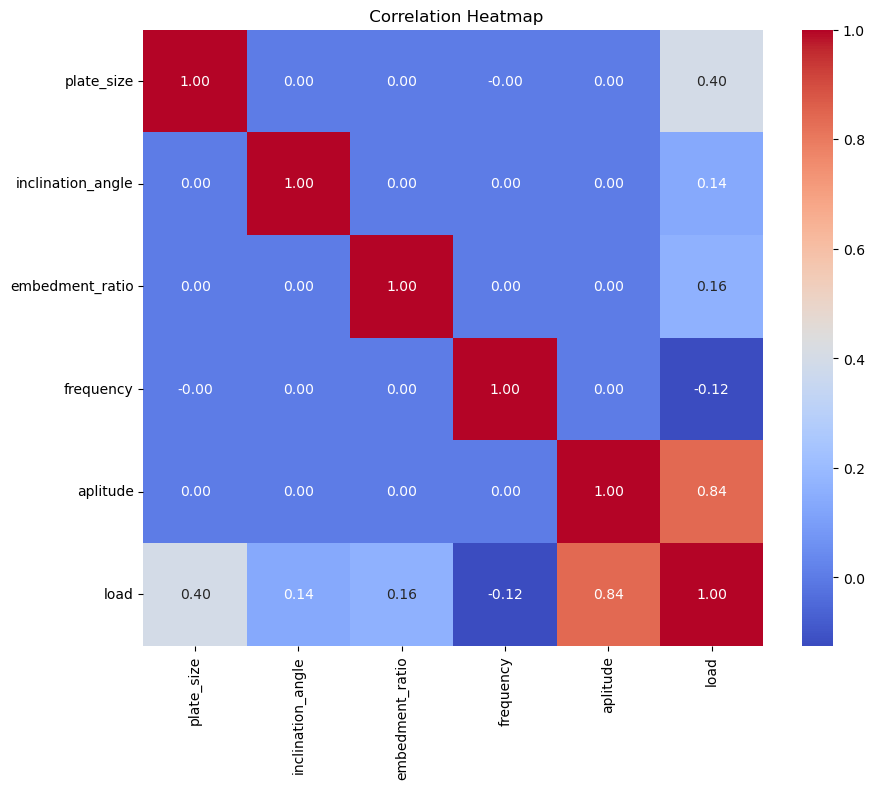

In [5]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title(" Correlation Heatmap")
plt.show()


### DATA ENCODING

In [6]:
print("Soil types present:", df["soil_type"].unique())

df_encoded = pd.get_dummies(df, columns=["soil_type"], drop_first=True)

Soil types present: ['unreinforced' 'reinforced']


##### Dataset Before Encoding

In [7]:
print("Fig. 3.7: Dataset Before Encoding")

# Columns used before encoding
before_encoding_cols = [
    "plate_size",
    "inclination_angle",
    "embedment_ratio",
    "frequency",
    "soil_type",
    "load"
]

# Select 5 samples from each soil type
df_unreinforced = df[df["soil_type"] == "unreinforced"][before_encoding_cols].head(5)
df_reinforced   = df[df["soil_type"] == "reinforced"][before_encoding_cols].tail(5)

# Combine for display
df_before_encoding = pd.concat([df_unreinforced, df_reinforced], axis=0).reset_index(drop=True)

display(df_before_encoding)


Fig. 3.7: Dataset Before Encoding


,plate_size,inclination_angle,embedment_ratio,frequency,soil_type,load
0,25,30,1,0.2,unreinforced,30.100
1,25,30,2,0.2,unreinforced,35.910
2,25,30,3,0.2,unreinforced,39.130
3,25,45,1,0.2,unreinforced,32.200
4,25,45,2,0.2,unreinforced,35.970
5,75,45,2,0.5,reinforced,155.227
6,75,45,3,0.5,reinforced,169.075
7,75,60,1,0.5,reinforced,139.151
8,75,60,2,0.5,reinforced,163.421
9,75,60,3,0.5,reinforced,179.377


#####  Dataset After Encoding

In [8]:
print("Fig. 3.8: Dataset After Encoding")

# One-hot encode soil_type (NO drop_first to show full encoding clearly)
df_encoded = pd.get_dummies(df, columns=["soil_type"], drop_first=False)

# Columns after encoding
after_encoding_cols = [
    "plate_size",
    "inclination_angle",
    "embedment_ratio",
    "frequency",
    "soil_type_unreinforced",
    "soil_type_reinforced",
    "load"
]

# Select 5 samples from each soil type using encoded columns
df_unreinforced_enc = df_encoded[df_encoded["soil_type_unreinforced"] == 1][after_encoding_cols].head(5)
df_reinforced_enc   = df_encoded[df_encoded["soil_type_reinforced"] == 1][after_encoding_cols].tail(5)

# Combine for display
df_after_encoding = pd.concat(
    [df_unreinforced_enc, df_reinforced_enc],
    axis=0
).reset_index(drop=True)

display(df_after_encoding)


Fig. 3.8: Dataset After Encoding


,plate_size,inclination_angle,embedment_ratio,frequency,soil_type_unreinforced,soil_type_reinforced,load
0,25,30,1,0.2,True,False,30.100
1,25,30,2,0.2,True,False,35.910
2,25,30,3,0.2,True,False,39.130
3,25,45,1,0.2,True,False,32.200
4,25,45,2,0.2,True,False,35.970
5,75,45,2,0.5,False,True,155.227
6,75,45,3,0.5,False,True,169.075
7,75,60,1,0.5,False,True,139.151
8,75,60,2,0.5,False,True,163.421
9,75,60,3,0.5,False,True,179.377


## Feature & Scaling

##### Feature–Target Separation

In [9]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_encoded.drop("load", axis=1)
y = df_encoded["load"]

print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (216, 7)
y shape: (216,)


#### Train–Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train/Test split done")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


Train/Test split done
X_train: (172, 7)
X_test : (44, 7)


#### Feature Scaling

In [11]:
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")


Feature scaling completed


## K-FOLD

In [12]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "R2": "r2",
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "MAPE": "neg_mean_absolute_percentage_error"
}

results_store = {}

print("10-Fold Cross Validation initialized")


10-Fold Cross Validation initialized


## Linear Regression 

In [13]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop("load", axis=1)
y = df_encoded["load"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [14]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import max_error
import numpy as np

print("TRAINING SIMPLE LINEAR REGRESSION...")


lr_model = LinearRegression()


scores = cross_validate(
    lr_model,
    X_scaled,
    y,
    cv=kf,              # ✅ same 10-fold CV
    scoring=scoring
)


me_scores = []
for tr, ts in kf.split(X_scaled):
    lr_model.fit(X_scaled[tr], y.iloc[tr])
    pred = lr_model.predict(X_scaled[ts])
    me_scores.append(max_error(y.iloc[ts], pred))


results_store["Simple Linear Regression"] = {
    "model": lr_model,
    "scores": scores,
    "me": me_scores
}


print("\nLinear Regression Performance:")
print("R2   :", np.mean(scores["test_R2"]))
print("MAE  :", -np.mean(scores["test_MAE"]))
print("MSE  :", -np.mean(scores["test_MSE"]))
print("MAPE :", -np.mean(scores["test_MAPE"]))
print("ME   :", np.mean(me_scores))



TRAINING SIMPLE LINEAR REGRESSION...

Linear Regression Performance:
R2   : 0.9314960182895075
MAE  : 8.746448888911047
MSE  : 115.98792762550404
MAPE : 0.1333872534257428
ME   : 23.667037623938903


## RANDOM FOREST REGRESSION

In [15]:


print("TRAINING RANDOM FOREST REGRESSOR...")


# Hyperparameter search space

rf_params = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}


rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    n_iter=10,
    cv=kf,              # ✅ same K-Fold as thesis
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_scaled, y)
best_rf = rf_search.best_estimator_

print("Best RF Parameters:", rf_search.best_params_)


scores = cross_validate(
    best_rf,
    X_scaled,
    y,
    cv=kf,
    scoring=scoring
)


me_scores = []
for tr, ts in kf.split(X_scaled):
    best_rf.fit(X_scaled[tr], y.iloc[tr])
    pred = best_rf.predict(X_scaled[ts])
    me_scores.append(max_error(y.iloc[ts], pred))


results_store["Random Forest Regressor"] = {
    "model": best_rf,
    "scores": scores,
    "me": me_scores
}


print("\nRandom Forest Performance:")
print("R2   :", np.mean(scores["test_R2"]))
print("MAE  :", -np.mean(scores["test_MAE"]))
print("MSE  :", -np.mean(scores["test_MSE"]))
print("MAPE :", -np.mean(scores["test_MAPE"]))
print("ME   :", np.mean(me_scores))



TRAINING RANDOM FOREST REGRESSOR...
Best RF Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}

Random Forest Performance:
R2   : 0.9828846419371233
MAE  : 3.7361593800865966
MSE  : 29.233008293198516
MAPE : 0.04386141054693876
ME   : 14.59338240000002


## SGD REGRESSOR

In [60]:

from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import max_error
import numpy as np

print("TRAINING SGD REGRESSOR...")

# Hyperparameter space
sgd_params = {
    "alpha": [0.0001, 0.001, 0.01],
    "penalty": ["l2", "elasticnet"],
    "max_iter": [2000, 3000, 4000]
}

# Randomized Search with SAME k-fold
sgd_search = RandomizedSearchCV(
    SGDRegressor(random_state=42),
    sgd_params,
    n_iter=10,
    cv=kf,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

# Fit on FULL SCALED DATA
sgd_search.fit(X_scaled, y)

# Best model
best_sgd = sgd_search.best_estimator_

print("Best SGD Parameters:", sgd_search.best_params_)

# Cross-validation metrics
scores = cross_validate(
    best_sgd,
    X_scaled,
    y,
    cv=kf,
    scoring=scoring
)

# Max error
me_scores = []
for tr, ts in kf.split(X_scaled):
    best_sgd.fit(X_scaled[tr], y.iloc[tr])
    pred = best_sgd.predict(X_scaled[ts])
    me_scores.append(max_error(y.iloc[ts], pred))

# Store results
results_store["SGD Regressor"] = {
    "model": best_sgd,
    "scores": scores,
    "me": me_scores
}

print("\nSGD Regressor Performance:")
print("R2   :", np.mean(scores["test_R2"]))
print("MAE  :", -np.mean(scores["test_MAE"]))
print("MSE  :", -np.mean(scores["test_MSE"]))
print("MAPE :", -np.mean(scores["test_MAPE"]))
print("ME   :", np.mean(me_scores))


TRAINING SGD REGRESSOR...
Best SGD Parameters: {'penalty': 'elasticnet', 'max_iter': 2000, 'alpha': 0.01}

SGD Regressor Performance:
R2   : 0.9315739290213616
MAE  : 8.715079289505024
MSE  : 116.22733246386431
MAPE : 0.13150630969544524
ME   : 24.06569475811154


## XGBOOST REGRESSOR

In [17]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb_params = {
    "n_estimators": [500, 1000],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9]
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),
    xgb_params,
    n_iter=10,
    cv=kf,             
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_scaled, y)
best_xgb = xgb_search.best_estimator_


scores = cross_validate(
    best_xgb,
    X_scaled,
    y,
    cv=kf,
    scoring=scoring
)


me_scores = []
for tr, ts in kf.split(X_scaled):
    best_xgb.fit(X_scaled[tr], y.iloc[tr])
    pred = best_xgb.predict(X_scaled[ts])
    me_scores.append(max_error(y.iloc[ts], pred))


results_store["XGBoost Regressor"] = {
    "model": best_xgb,
    "scores": scores,
    "me": me_scores
}

print("XGBoost Results:")
print("R2  :", np.mean(scores["test_R2"]))
print("MAE :", -np.mean(scores["test_MAE"]))
print("MSE :", -np.mean(scores["test_MSE"]))
print("MAPE:", -np.mean(scores["test_MAPE"]))
print("ME  :", np.mean(me_scores))


XGBoost Results:
R2  : 0.9980436813215464
MAE : 1.3207961156473527
MSE : 2.9976412583405887
MAPE: 0.018466324167993875
ME  : 4.401013861083982


## ANN REGRESSION

In [18]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.metrics import max_error
import numpy as np

print("TRAINING ANN (MLP REGRESSOR)...")

ann_params = {
    "hidden_layer_sizes": [(50,), (100,), (100, 50), (100, 100)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01]
}


ann_search = RandomizedSearchCV(
    MLPRegressor(
        max_iter=3000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    ),
    ann_params,
    n_iter=10,
    cv=kf,           
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

ann_search.fit(X_scaled, y)
best_ann = ann_search.best_estimator_

print("Best ANN Parameters:", ann_search.best_params_)


scores = cross_validate(
    best_ann,
    X_scaled,
    y,
    cv=kf,
    scoring=scoring
)


me_scores = []
for tr, ts in kf.split(X_scaled):
    best_ann.fit(X_scaled[tr], y.iloc[tr])
    pred = best_ann.predict(X_scaled[ts])
    me_scores.append(max_error(y.iloc[ts], pred))

# -----------------------------
# Store results
# -----------------------------
results_store["ANN (MLP Regressor)"] = {
    "model": best_ann,
    "scores": scores,
    "me": me_scores
}


print("\nANN Performance:")
print("R2   :", np.mean(scores["test_R2"]))
print("MAE  :", -np.mean(scores["test_MAE"]))
print("MSE  :", -np.mean(scores["test_MSE"]))
print("MAPE :", -np.mean(scores["test_MAPE"]))
print("ME   :", np.mean(me_scores))


TRAINING ANN (MLP REGRESSOR)...
Best ANN Parameters: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (100,), 'alpha': 0.0001, 'activation': 'tanh'}

ANN Performance:
R2   : 0.978602253760888
MAE  : 3.731677229625138
MSE  : 42.11520495370753
MAPE : 0.045530787667324484
ME   : 19.025980767927486


## 1D-CNN

##### Reshape input for CNN

In [19]:
X_cnn = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_cnn, y, test_size=0.2, random_state=42
)


##### Define 1D-CNN Model

In [20]:
def build_cnn_model(input_shape):
    model = Sequential()
    model.add(Conv1D(64, 2, activation="relu", input_shape=input_shape))
    model.add(MaxPooling1D(2))
    model.add(Conv1D(32, 2, activation="relu"))
    model.add(MaxPooling1D(2))
    model.add(Flatten())
    model.add(Dense(64, activation="relu"))
    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )
    return model



##### Train & Evaluate

In [21]:
print("TRAINING 1D-CNN REGRESSOR ")

cnn_r2, cnn_mae, cnn_mse, cnn_mape, cnn_me = [], [], [], [], []

for tr, ts in kf.split(X_cnn):

    model = build_cnn_model(
        input_shape=(X_cnn.shape[1], 1)
    )

    model.fit(
        X_cnn[tr], y.iloc[tr],
        epochs=100,
        batch_size=16,
        verbose=0
    )

    y_pred = model.predict(X_cnn[ts]).flatten()
    y_true = y.iloc[ts].values

    cnn_r2.append(r2_score(y_true, y_pred))
    cnn_mae.append(mean_absolute_error(y_true, y_pred))
    cnn_mse.append(mean_squared_error(y_true, y_pred))
    cnn_mape.append(np.mean(np.abs((y_true - y_pred) / y_true)))
    cnn_me.append(max_error(y_true, y_pred))

# ✅ store AFTER loop
results_store["1D-CNN Regressor"] = {
    "model": "1D-CNN (KFold)",
    "scores": {
        "test_R2": np.array(cnn_r2),
        "test_MAE": -np.array(cnn_mae),
        "test_MSE": -np.array(cnn_mse),
        "test_MAPE": -np.array(cnn_mape)
    },
    "me": cnn_me
}
cnn1d_model = build_cnn_model(
    input_shape=(X_train_seq.shape[1], 1)
)

cnn1d_model.fit(
    X_train_seq, y_train_seq,
    epochs=150,
    batch_size=16,
    verbose=0
)


print("\n📊 1D-CNN K-FOLD PERFORMANCE")
print("--------------------------------")
print("R2   :", np.mean(cnn_r2))
print("MAE  :", np.mean(cnn_mae))
print("MSE  :", np.mean(cnn_mse))
print("MAPE :", np.mean(cnn_mape))
print("ME   :", np.mean(cnn_me))



TRAINING 1D-CNN REGRESSOR 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

📊 1D-CNN K-FOLD PERFORMANCE
--------------------------------
R2   : 0.3192536994277777
MAE  : 26.202607629850313
MSE  : 1105.271192093383
MAPE : 0.3893647691531633
ME   : 75.23070965576173


### SUMMARY OF EVALUATION RESULTS

In [22]:


print("GENERATING SUMMARY OF EVALUATION RESULTS...")

summary_rows = []

for name, data in results_store.items():
    
    scores = data["scores"]
    
    summary_rows.append({
        "Model": name,
        "R2 Score": np.mean(scores["test_R2"]),
        "MAE": -np.mean(scores["test_MAE"]),
        "MSE": -np.mean(scores["test_MSE"]),
        "MAPE": -np.mean(scores["test_MAPE"]),
        "ME": np.mean(data["me"])   # ✅ ME explicitly added
    })

summary_df = pd.DataFrame(summary_rows)

# Sort models by performance
summary_df = summary_df.sort_values(
    by=["R2 Score", "MAE"],
    ascending=[False, True]
).reset_index(drop=True)

print("\nTABLE SUMMARY OF EVALUATION RESULTS")
display(summary_df)



GENERATING SUMMARY OF EVALUATION RESULTS...

TABLE SUMMARY OF EVALUATION RESULTS


,Model,R2 Score,MAE,MSE,MAPE,ME
0,XGBoost Regressor,0.998044,1.320796,2.997641,0.018466,4.401014
1,Random Forest Regressor,0.982885,3.736159,29.233008,0.043861,14.593382
2,ANN (MLP Regressor),0.978602,3.731677,42.115205,0.045531,19.025981
3,SGD Regressor,0.931574,8.715079,116.227332,0.131506,24.065695
4,Simple Linear Regression,0.931496,8.746449,115.987928,0.133387,23.667038
5,1D-CNN Regressor,0.319254,26.202608,1105.271192,0.389365,75.230710


####  BOX PLOTS FOR ALL MODELS

GENERATING ENHANCED BOX PLOTS FOR ALL MODELS...


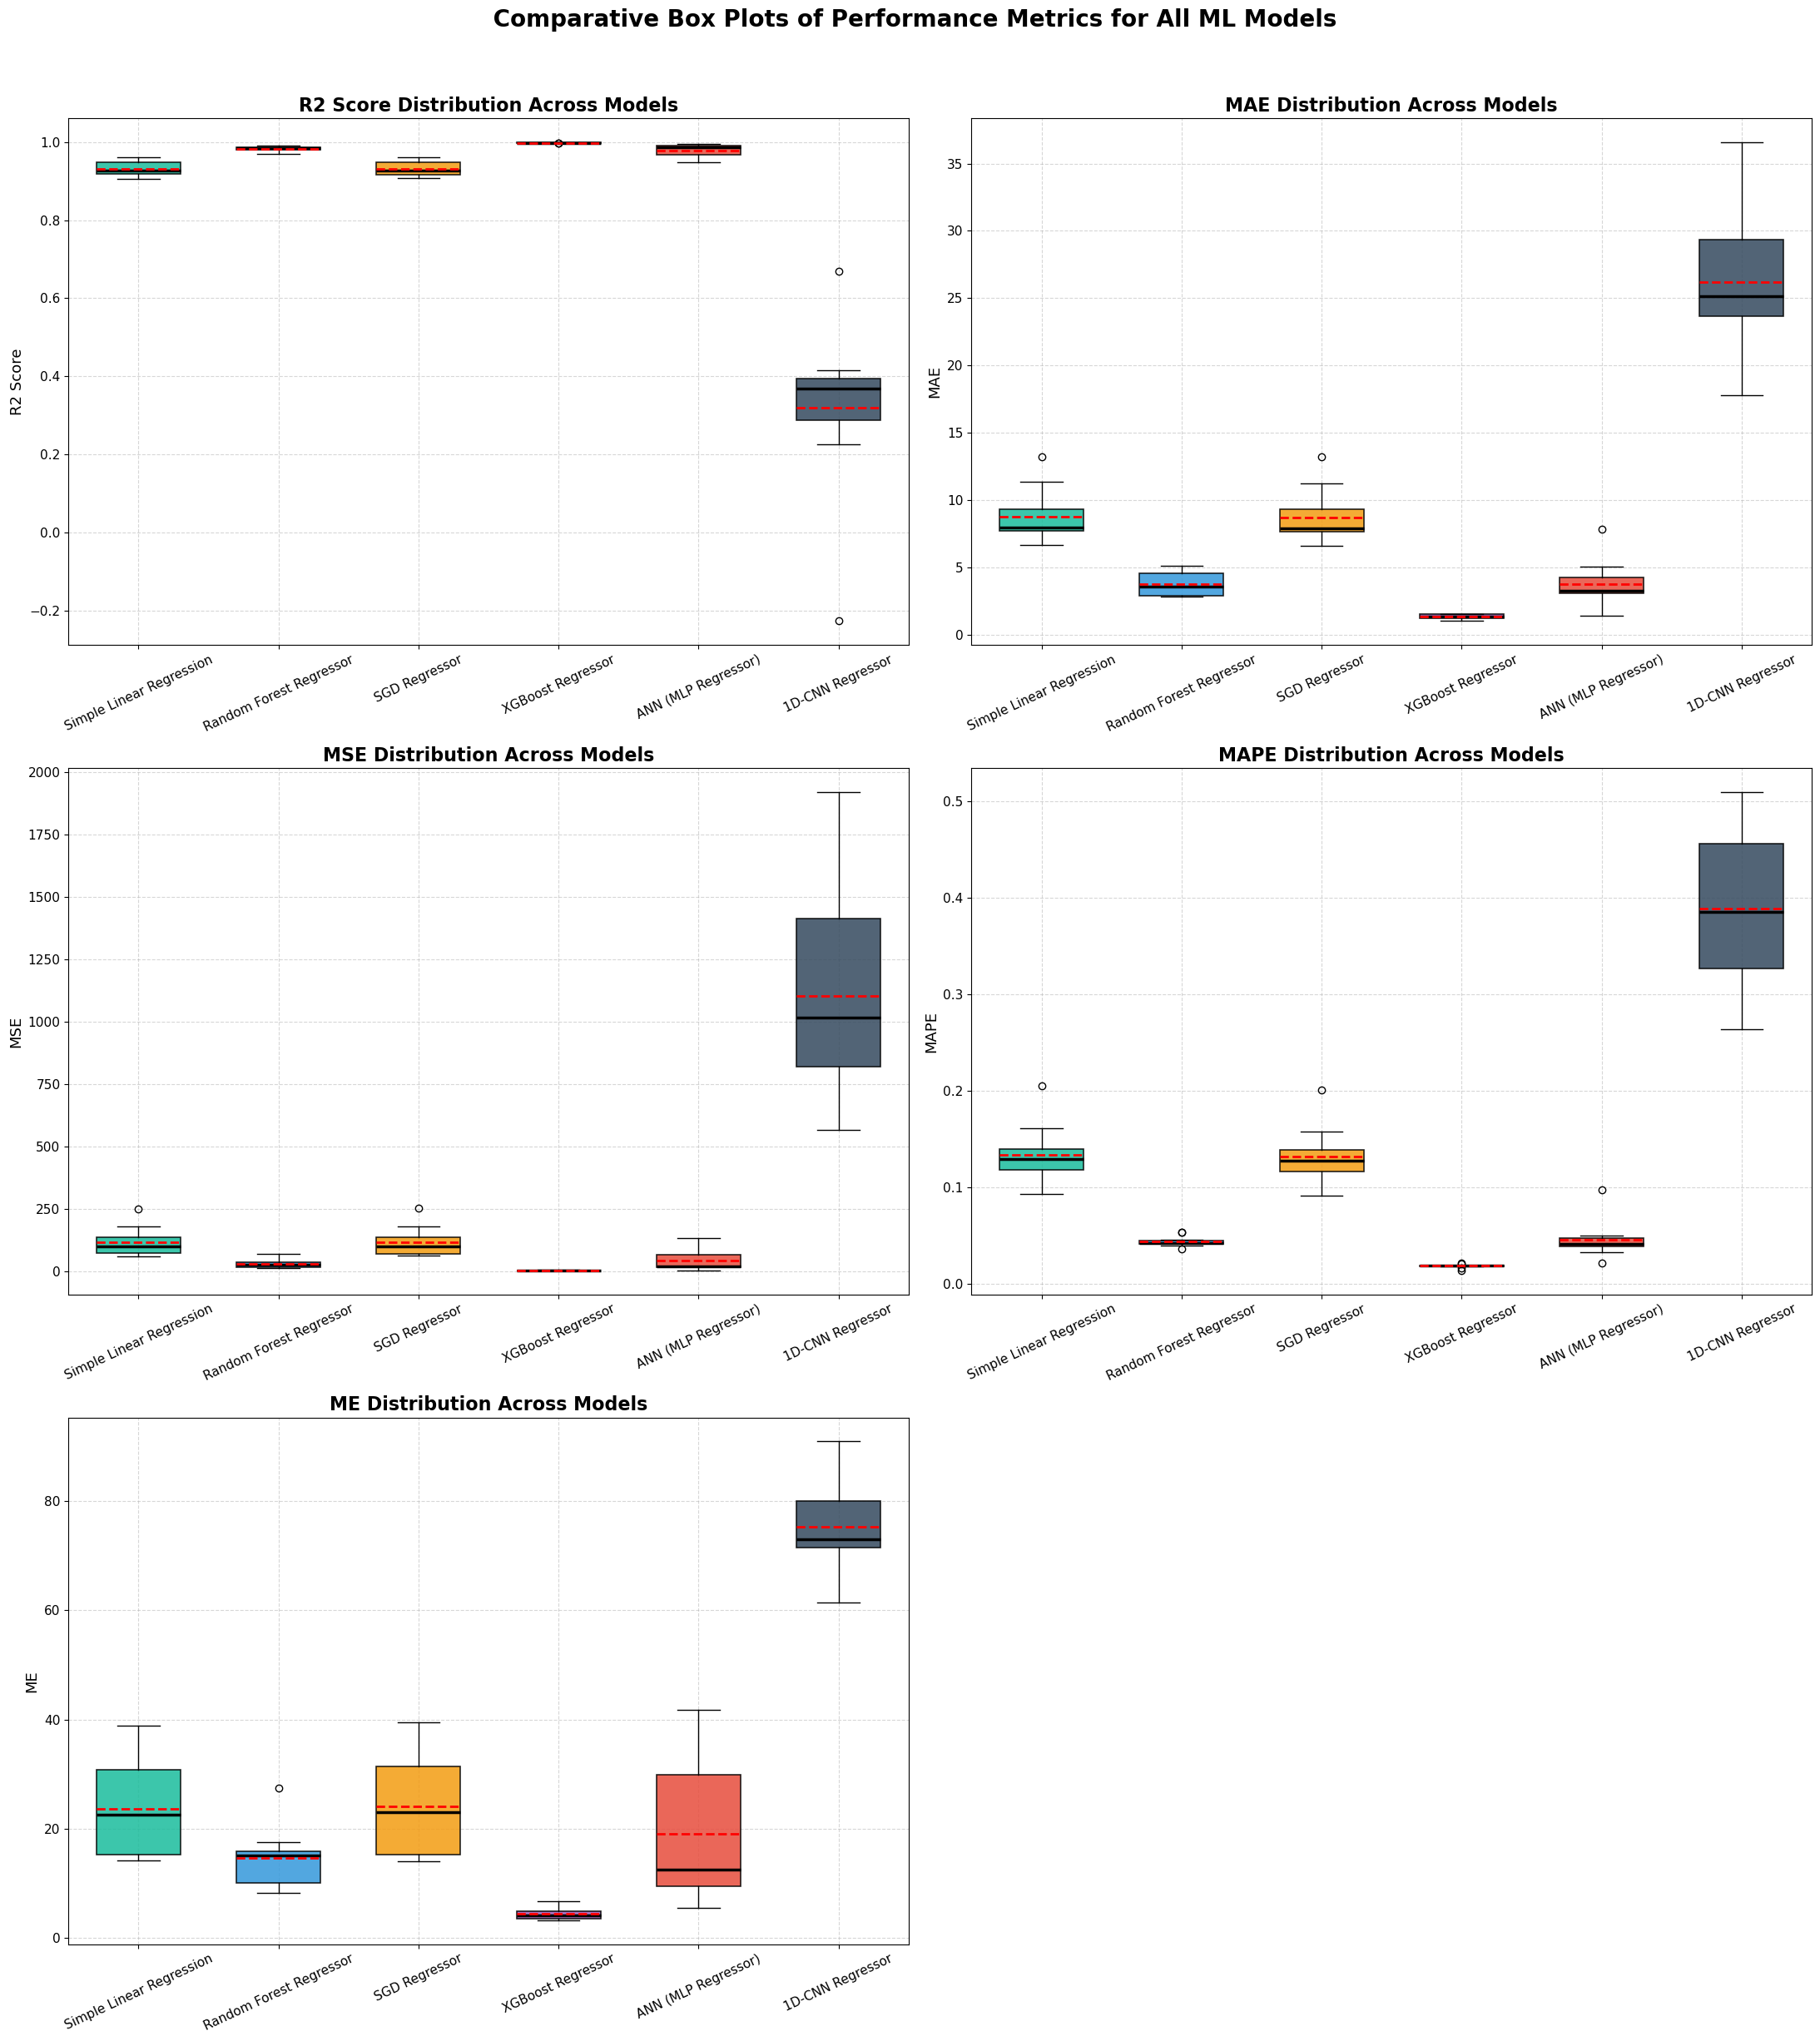

In [23]:

import matplotlib.pyplot as plt
import numpy as np

print("GENERATING ENHANCED BOX PLOTS FOR ALL MODELS...")

# Metrics mapping
metrics = {
    "R2 Score": "test_R2",
    "MAE": "test_MAE",
    "MSE": "test_MSE",
    "MAPE": "test_MAPE",
    "ME": "me"
}

# Bigger figure
fig, axes = plt.subplots(3, 2, figsize=(22, 24))
axes = axes.flatten()

# Distinct bright colors
colors = [
    "#1abc9c", "#3498db", "#f39c12",
    "#9b59b6", "#e74c3c", "#34495e"
]

for i, (metric_name, key) in enumerate(metrics.items()):
    
    data_to_plot = []
    labels = []
    
    for model_name, data in results_store.items():
        if key == "me":
            values = data["me"]
        else:
            values = data["scores"][key]
            if metric_name in ["MAE", "MSE", "MAPE"]:
                values = -values   # convert from negative scoring
        
        data_to_plot.append(values)
        labels.append(model_name)
    
    box = axes[i].boxplot(
        data_to_plot,
        patch_artist=True,
        labels=labels,
        showmeans=True,
        meanline=True,
        widths=0.6
    )
    
    # Color styling
    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
        patch.set_edgecolor("black")
        patch.set_linewidth(1.2)
    
    # Median styling
    for median in box["medians"]:
        median.set(color="black", linewidth=2.5)
    
    # Mean styling
    for mean in box["means"]:
        mean.set(color="red", linewidth=2, linestyle="--")
    
    axes[i].set_title(
        f"{metric_name} Distribution Across Models",
        fontsize=16,
        fontweight="bold"
    )
    axes[i].set_ylabel(metric_name, fontsize=13)
    axes[i].tick_params(axis="x", rotation=25, labelsize=11)
    axes[i].tick_params(axis="y", labelsize=11)
    axes[i].grid(True, linestyle="--", alpha=0.5)

# Remove extra subplot
if len(metrics) < len(axes):
    axes[-1].axis("off")

plt.suptitle(
    " Comparative Box Plots of Performance Metrics for All ML Models",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()




####  Range-wise representative selection using median valuesafter sorting actual uplift load.

In [35]:
def range_wise_representative(y_actual, y_pred, n_ranges=10):
    """
    Range-wise representative selection using median values
    after sorting actual uplift load.
    Suitable for Linear Regression, RF, SGD, XGBoost, ANN, and 1D-CNN.
    """

    # -----------------------------
    # Safety check (VERY IMPORTANT)
    # -----------------------------
    if len(y_actual) != len(y_pred):
        raise ValueError(
            "Length mismatch: y_actual and y_pred must be of same size"
        )

    df_tmp = pd.DataFrame({
        "actual": y_actual,
        "pred": y_pred
    })

    # Sort by actual values (Sir's requirement)
    df_tmp = df_tmp.sort_values("actual").reset_index(drop=True)

    # Split into equal-sized ranges
    bins = np.array_split(df_tmp, n_ranges)

    rep_actual = []
    rep_pred = []
    rows = []

    for i, b in enumerate(bins):
        actual_median = b["actual"].median()
        pred_median   = b["pred"].median()

        rep_actual.append(actual_median)
        rep_pred.append(pred_median)

        rows.append({
            "Range No": f"Range {i+1}",
            "Actual Load Min": round(b["actual"].min(), 2),
            "Actual Load Max": round(b["actual"].max(), 2),
            "Actual Median (Used in Plot)": round(actual_median, 2),
            "Predicted Median (Used in Plot)": round(pred_median, 2),
            "Samples in Range": len(b)
        })

    range_table = pd.DataFrame(rows)

    return np.array(rep_actual), np.array(rep_pred), range_table



## Linear Regression

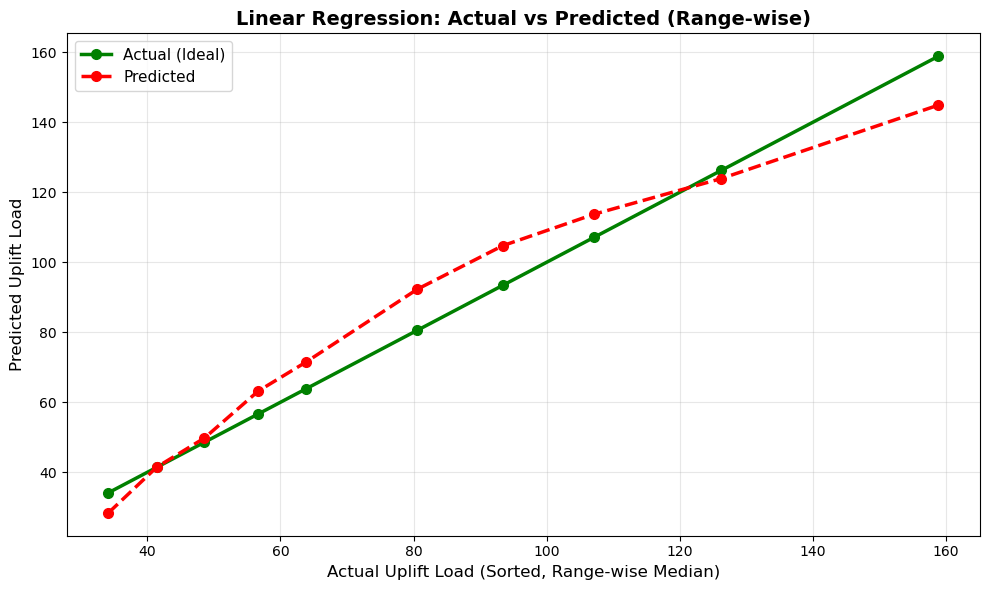

In [40]:



# 1. Train final Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Predict on test set
y_pred = lr_model.predict(X_test)
y_actual = y_test.values

# 3. Range-wise representative selection
rep_actual, rep_pred, range_table_lr = range_wise_representative(
    y_actual,
    y_pred,
    n_ranges=10
)



# 4. Plot
plt.figure(figsize=(10, 6))

# Ideal line (Actual vs Actual)
plt.plot(
    rep_actual,
    rep_actual,
    color="green",
    linewidth=2.5,
    marker="o",
    markersize=7,
    label="Actual (Ideal)"
)

# Predicted curve
plt.plot(
    rep_actual,
    rep_pred,
    color="red",
    linestyle="--",
    linewidth=2.5,
    marker="o",
    markersize=7,
    label="Predicted"
)

# Labels and title
plt.xlabel(
    "Actual Uplift Load (Sorted, Range-wise Median)",
    fontsize=12
)
plt.ylabel(
    "Predicted Uplift Load",
    fontsize=12
)

plt.title(
    "Linear Regression: Actual vs Predicted (Range-wise)",
    fontsize=14,
    fontweight="bold"
)

# Grid & legend
plt.grid(alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()



## Random forest 

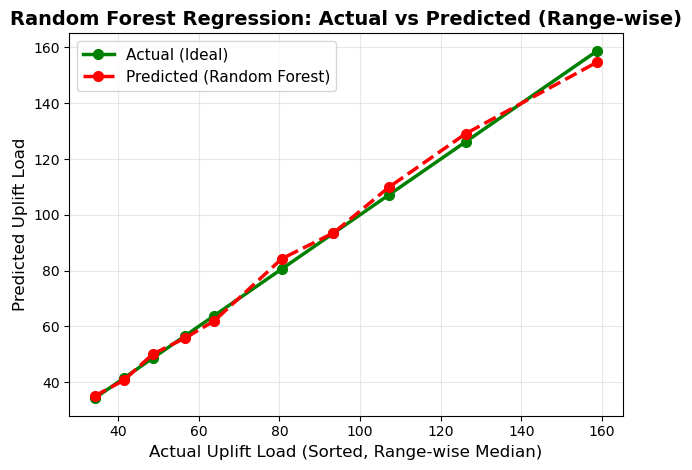

In [39]:



# Train RF on training data
best_rf.fit(X_train, y_train)

# Predict on test data
y_pred = best_rf.predict(X_test)
y_actual = y_test.values

# Range-wise representative values
rep_actual, rep_pred, range_table_rf = range_wise_representative(
    y_actual,
    y_pred,
    n_ranges=10
)





# Actual (Ideal)
plt.plot(
    rep_actual,
    rep_actual,
    color="green",
    linewidth=2.5,
    marker="o",
    markersize=7,
    label="Actual (Ideal)"
)

# Random Forest predicted behaviour
plt.plot(
    rep_actual,
    rep_pred,
    color="red",
    linestyle="--",
    linewidth=2.5,
    marker="o",
    markersize=7,
    label="Predicted (Random Forest)"
)

plt.xlabel(
    "Actual Uplift Load (Sorted, Range-wise Median)",
    fontsize=12
)
plt.ylabel(
    "Predicted Uplift Load",
    fontsize=12
)

plt.title(
    "Random Forest Regression: Actual vs Predicted (Range-wise)",
    fontsize=14,
    fontweight="bold"
)

plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()




## SGD REGRESSOR

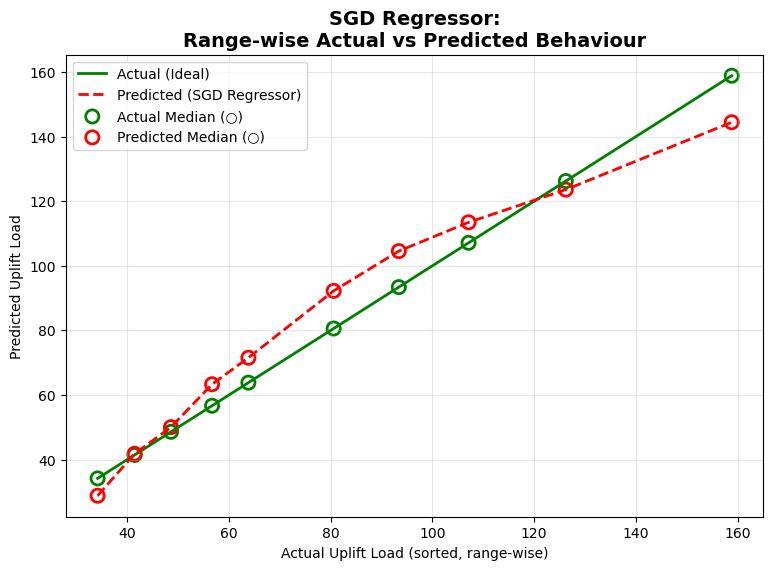

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---- TRAIN–TEST SPLIT ON SCALED DATA (MANDATORY) ----
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Fit SGD on TRAIN SET ONLY
best_sgd.fit(X_train, y_train)

# Predict on SCALED TEST SET
y_pred = best_sgd.predict(X_test)
y_actual = y_test.values

# Sort by actual uplift load (X-axis rule)
df_plot = pd.DataFrame({
    "actual": y_actual,
    "pred": y_pred
}).sort_values("actual").reset_index(drop=True)

# Range-wise split
n_ranges = 10
bins = np.array_split(df_plot, n_ranges)

# Median representatives
rep_actual = np.array([b["actual"].median() for b in bins])
rep_pred   = np.array([b["pred"].median() for b in bins])

# ---- PLOT ----
plt.figure(figsize=(9,6))

# Ideal line
plt.plot(
    rep_actual,
    rep_actual,
    color="green",
    linewidth=2,
    label="Actual (Ideal)"
)

# Predicted curve
plt.plot(
    rep_actual,
    rep_pred,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Predicted (SGD Regressor)"
)

# Green hollow circles (Actual median)
plt.scatter(
    rep_actual,
    rep_actual,
    facecolors="none",
    edgecolors="green",
    s=90,
    linewidths=2,
    label="Actual Median (○)"
)

# Red hollow circles (Predicted median)
plt.scatter(
    rep_actual,
    rep_pred,
    facecolors="none",
    edgecolors="red",
    s=90,
    linewidths=2,
    label="Predicted Median (○)"
)

plt.xlabel("Actual Uplift Load (sorted, range-wise)")
plt.ylabel("Predicted Uplift Load")
plt.title(
    "SGD Regressor:\nRange-wise Actual vs Predicted Behaviour",
    fontsize=14,
    fontweight="bold"
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()


## XGBoost

In [53]:
from xgboost import XGBRegressor

# Final XGBoost model for plotting
xgb_final = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)

# Fit on TRAIN data (y is ORIGINAL, not scaled)
xgb_final.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [54]:
# Predict on test set
y_pred = xgb_final.predict(X_test)
y_actual = y_test.values


In [55]:
# Predict on test set
y_pred = xgb_final.predict(X_test)
y_actual = y_test.values


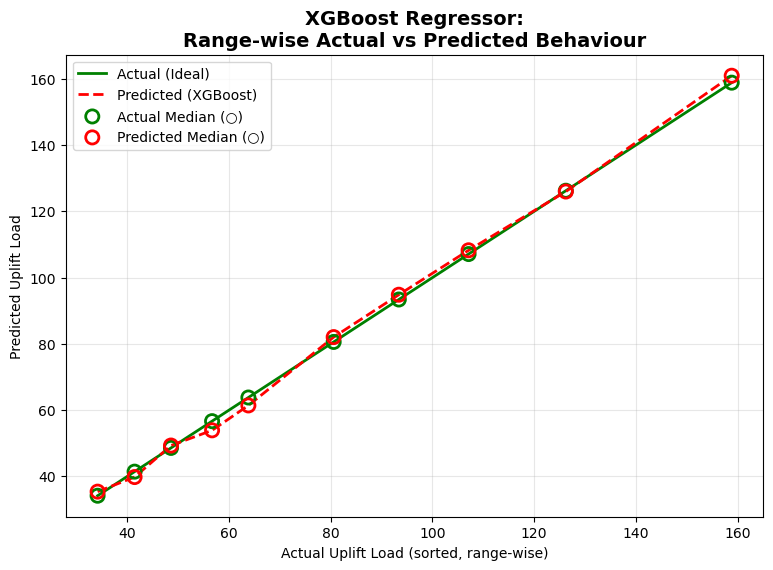

In [57]:


# Predict using trained best_xgb
y_pred = best_xgb.predict(X_test)
y_actual = y_test.values

# Create dataframe & sort by actual values (X-axis requirement)
df_plot = pd.DataFrame({
    "actual": y_actual,
    "pred": y_pred
}).sort_values("actual")

# Number of ranges (low → mid → high)
n_ranges = 10
bins = np.array_split(df_plot, n_ranges)

# Median representative values
rep_actual = np.array([b["actual"].median() for b in bins])
rep_pred   = np.array([b["pred"].median() for b in bins])


plt.figure(figsize=(9,6))

# Ideal line (Actual vs Actual)
plt.plot(
    rep_actual,
    rep_actual,
    color="green",
    linewidth=2,
    label="Actual (Ideal)"
)

# Predicted curve (XGBoost behaviour)
plt.plot(
    rep_actual,
    rep_pred,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Predicted (XGBoost)"
)

# Green circles → Actual median
plt.scatter(
    rep_actual,
    rep_actual,
    facecolors="none",
    edgecolors="green",
    s=90,
    linewidths=2,
    zorder=4,
    label="Actual Median (○)"
)

# Red circles → Predicted median
plt.scatter(
    rep_actual,
    rep_pred,
    facecolors="none",
    edgecolors="red",
    s=90,
    linewidths=2,
    zorder=5,
    label="Predicted Median (○)"
)

# Labels & title
plt.xlabel("Actual Uplift Load (sorted, range-wise)")
plt.ylabel("Predicted Uplift Load")
plt.title(
    "XGBoost Regressor:\nRange-wise Actual vs Predicted Behaviour",
    fontsize=14,
    fontweight="bold"
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()


## ANN

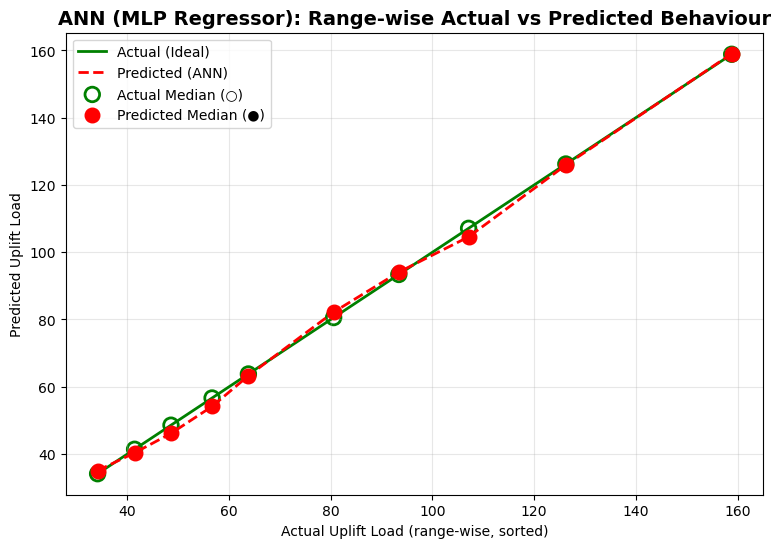

In [29]:


# Fit ANN on training data
best_ann.fit(X_train, y_train)

# Predict on test data
y_pred = best_ann.predict(X_test)
y_actual = y_test.values

# Create dataframe and sort by actual values
df_plot = pd.DataFrame({
    "actual": y_actual,
    "pred": y_pred
}).sort_values("actual")

# Number of ranges (Low → High)
n_ranges = 10
bins = np.array_split(df_plot, n_ranges)

# Median representative values from each range
rep_actual = np.array([b["actual"].median() for b in bins])
rep_pred   = np.array([b["pred"].median() for b in bins])

# Plot
plt.figure(figsize=(9,6))

# Ideal line (Actual vs Actual)
plt.plot(
    rep_actual,
    rep_actual,
    color="green",
    linewidth=2,
    label="Actual (Ideal)"
)

# ANN predicted curve
plt.plot(
    rep_actual,
    rep_pred,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Predicted (ANN)"
)

# Median points
plt.scatter(
    rep_actual, rep_actual,
    facecolors="none", edgecolors="green",
    s=110, linewidths=2,
    label="Actual Median (○)"
)

plt.scatter(
    rep_actual, rep_pred,
    color="red",
    s=110, zorder=3,
    label="Predicted Median (●)"
)

plt.xlabel("Actual Uplift Load (range-wise, sorted)")
plt.ylabel("Predicted Uplift Load")
plt.title(
    "ANN (MLP Regressor): Range-wise Actual vs Predicted Behaviour",
    fontsize=14, fontweight="bold"
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 1-D CNN REGRESSION

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


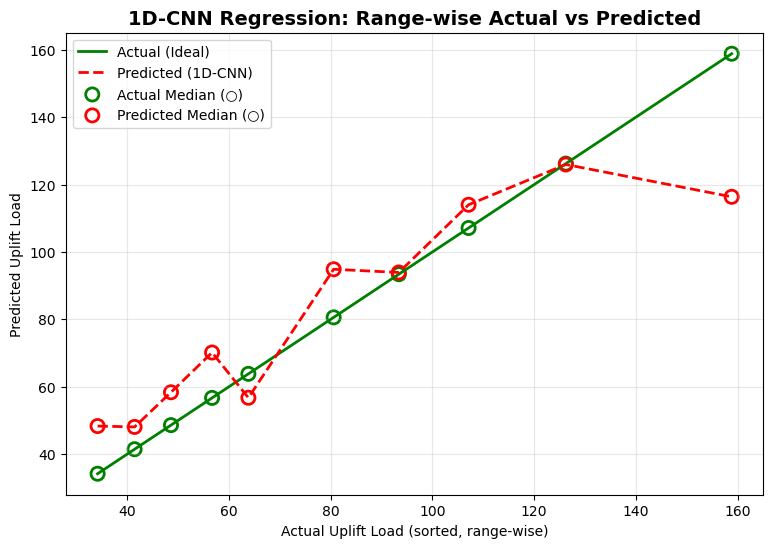

In [30]:


y_pred = cnn1d_model.predict(X_test_seq).flatten()
y_actual = y_test.values



df_plot = pd.DataFrame({
    "actual": y_actual,
    "pred": y_pred
}).sort_values("actual")


n_ranges = 10  # same as discussed with Sir
bins = np.array_split(df_plot, n_ranges)

rep_actual = np.array([b["actual"].median() for b in bins])
rep_pred   = np.array([b["pred"].median()   for b in bins])


plt.figure(figsize=(9, 6))


plt.plot(
    rep_actual, rep_actual,
    color="green", linewidth=2,
    label="Actual (Ideal)"
)

# Predicted curve
plt.plot(
    rep_actual, rep_pred,
    color="red", linestyle="--", linewidth=2,
    label="Predicted (1D-CNN)"
)


plt.scatter(
    rep_actual, rep_actual,
    facecolors="none", edgecolors="green",
    s=90, linewidths=2,
    label="Actual Median (○)"
)

plt.scatter(
    rep_actual, rep_pred,
    facecolors="none", edgecolors="red",
    s=90, linewidths=2,
    label="Predicted Median (○)"
)


plt.xlabel("Actual Uplift Load (sorted, range-wise)")
plt.ylabel("Predicted Uplift Load")
plt.title("1D-CNN Regression: Range-wise Actual vs Predicted",
          fontsize=14, fontweight="bold")

plt.grid(alpha=0.3)
plt.legend()
plt.show()



## RANGE DEFINITION & MEDIAN REPRESENTATION

In [62]:


n_ranges = 10  # Same value used in plotting


best_xgb.fit(X_train, y_train)
y_actual = y_test.values
y_pred = best_xgb.predict(X_test)


df_range = pd.DataFrame({
    "Actual_Uplift_Load": y_actual,
    "Predicted_Uplift_Load": y_pred
})


df_range = df_range.sort_values("Actual_Uplift_Load").reset_index(drop=True)


bins = np.array_split(df_range, n_ranges)


range_summary = []

for i, b in enumerate(bins, start=1):
    range_summary.append({
        "Range No": f"Range {i}",
        "Actual Load Min": round(b["Actual_Uplift_Load"].min(), 2),
        "Actual Load Max": round(b["Actual_Uplift_Load"].max(), 2),
        "Actual Median (Used in Plot)": round(b["Actual_Uplift_Load"].median(), 2),
        "Predicted Median (Used in Plot)": round(b["Predicted_Uplift_Load"].median(), 2),
        "Samples in Range": len(b)
    })

range_df = pd.DataFrame(range_summary)

print("RANGE-WISE REPRESENTATION USED FOR PLOTTING")
display(range_df)


RANGE-WISE REPRESENTATION USED FOR PLOTTING


,Range No,Actual Load Min,Actual Load Max,Actual Median (Used in Plot),Predicted Median (Used in Plot),Samples in Range
0,Range 1,31.24,37.32,34.15,35.38,5
1,Range 2,37.85,45.45,41.42,39.78,5
2,Range 3,47.09,49.46,48.58,49.30,5
3,Range 4,51.14,60.50,56.66,53.89,5
4,Range 5,60.98,70.07,63.80,61.40,4
5,Range 6,80.02,85.37,80.57,82.04,4
6,Range 7,85.85,100.07,93.39,94.83,4
7,Range 8,102.53,120.71,107.10,108.24,4
8,Range 9,121.45,139.15,126.23,125.98,4
9,Range 10,143.89,202.65,158.85,160.94,4


## BAR PLOTS

GENERATING BAR CHARTS (All Models)...


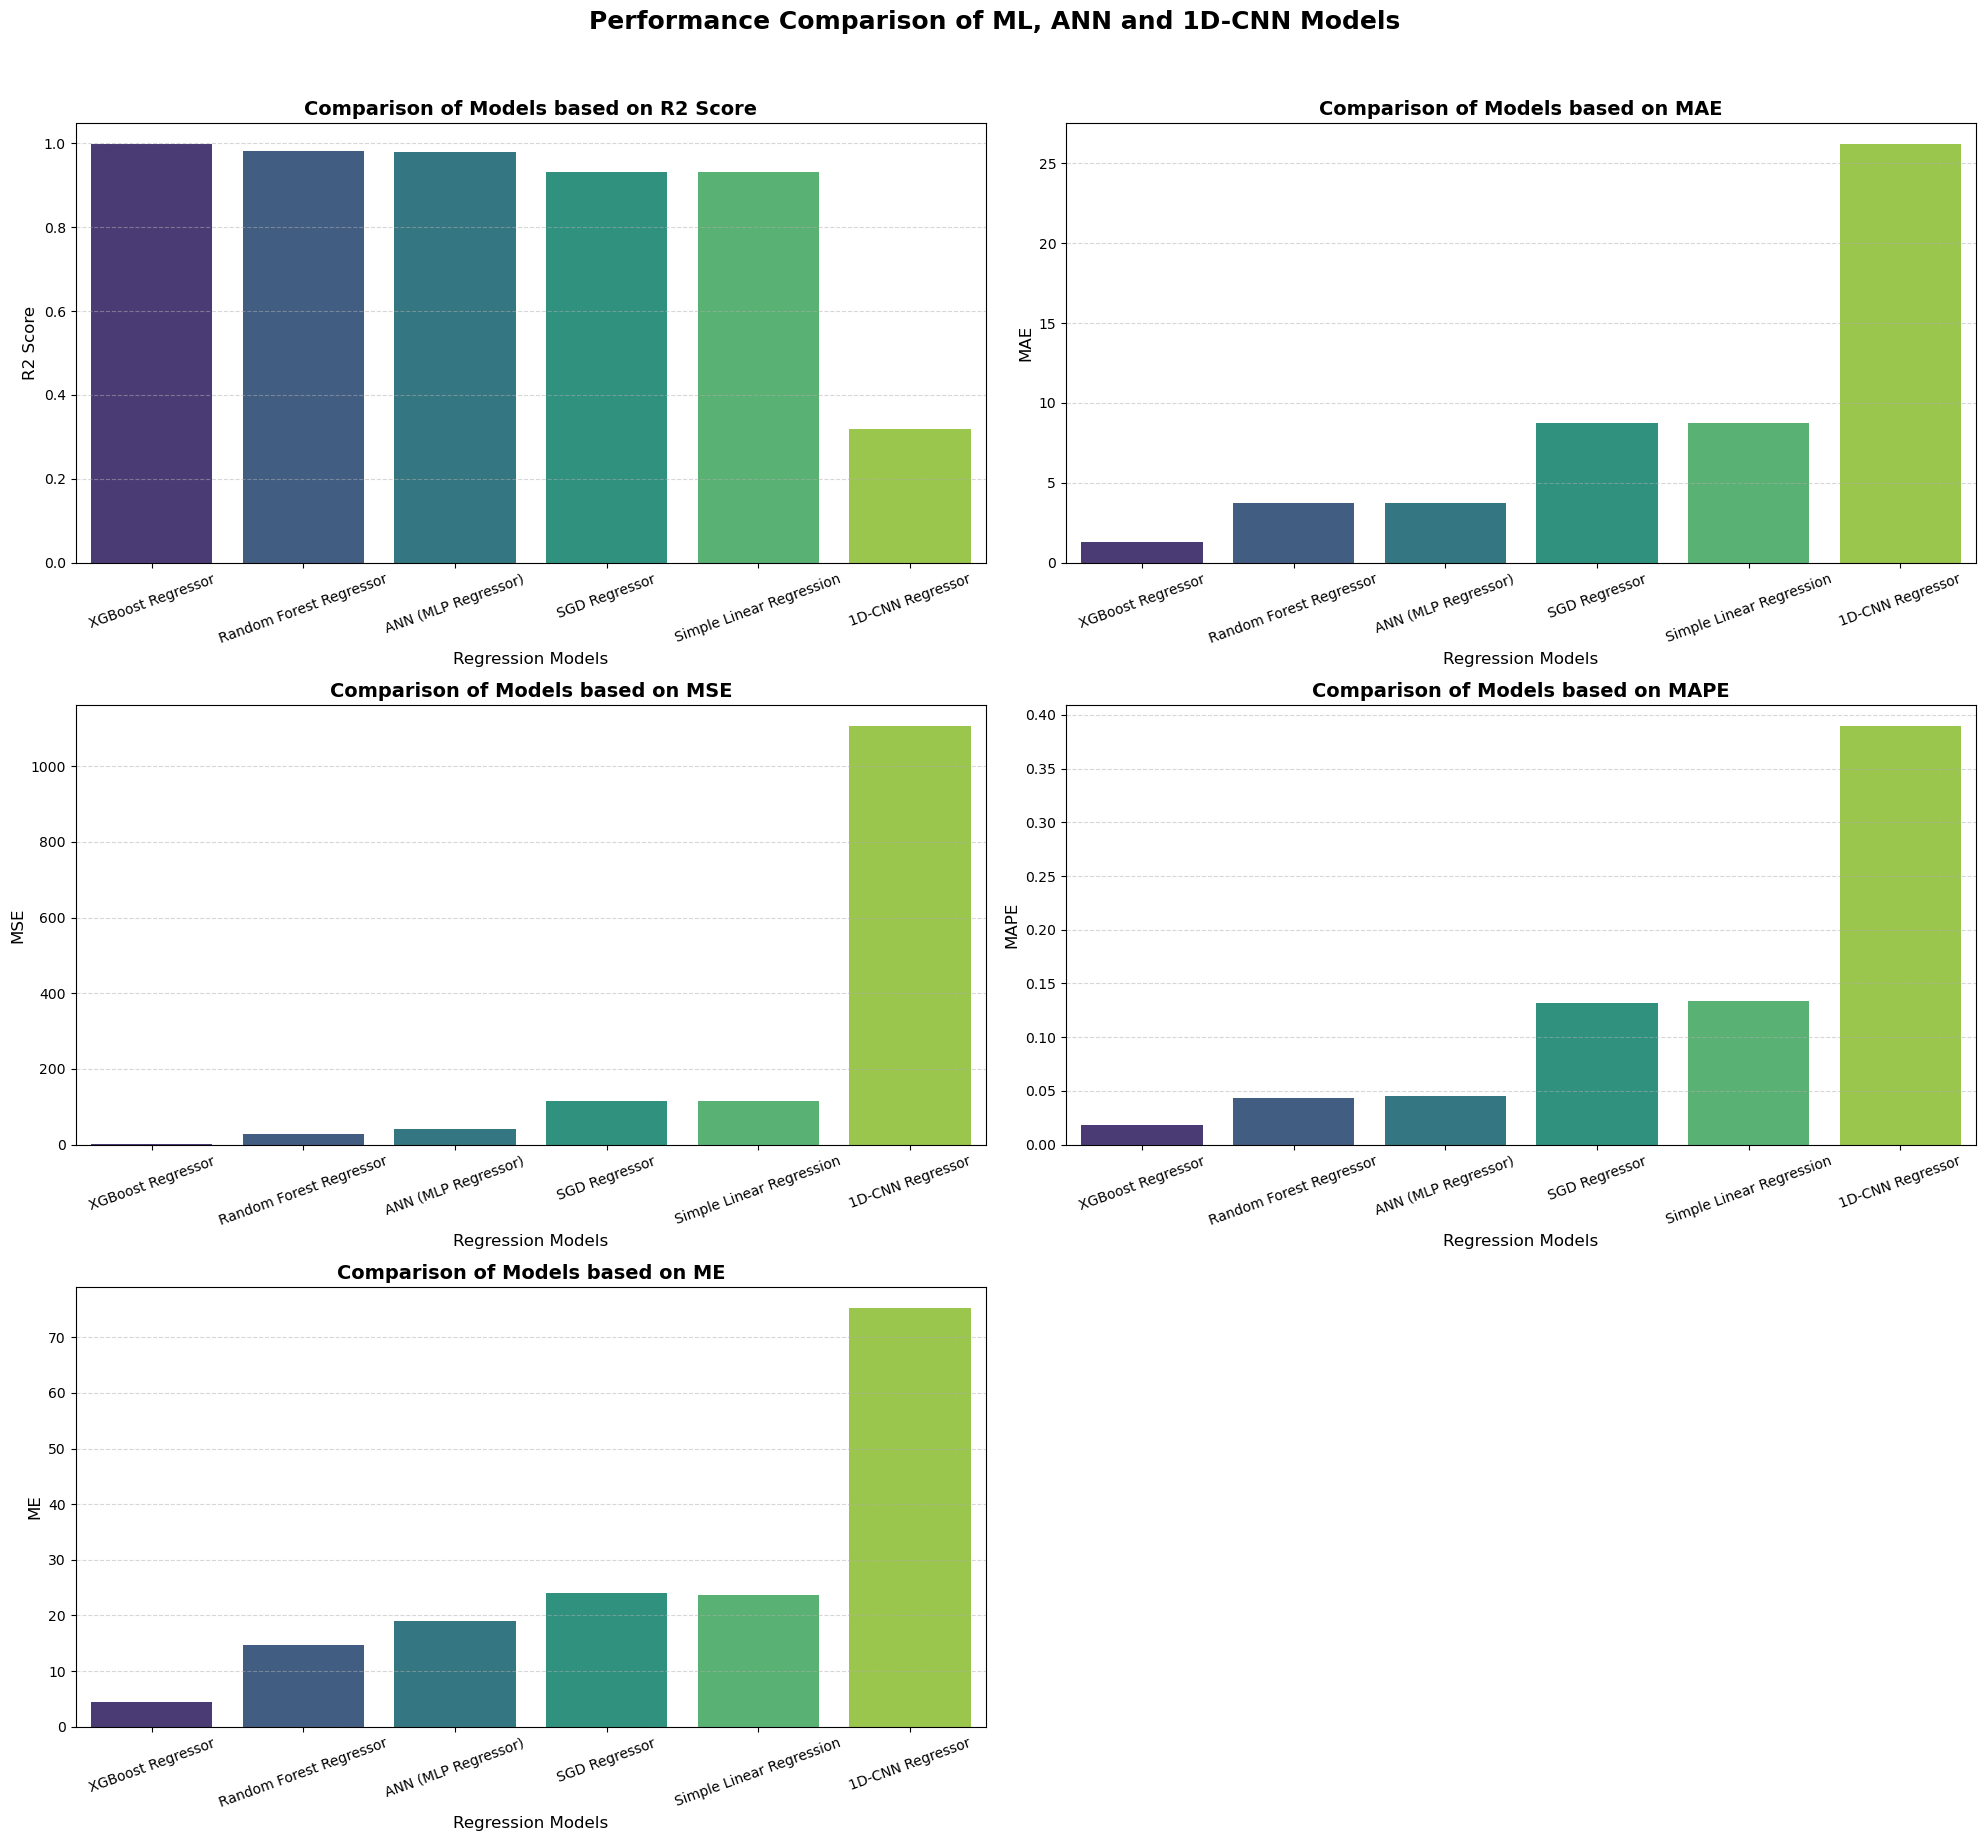

In [32]:
print("GENERATING BAR CHARTS (All Models)...")

import seaborn as sns
import matplotlib.pyplot as plt

# Metrics to plot (exclude Model column)
metrics = [col for col in summary_df.columns if col != "Model"]

# Figure setup
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(20, 18)
)

axes = axes.flatten()

# Color palette (eye-catching & consistent)
palette = sns.color_palette("viridis", n_colors=len(summary_df))

for i, metric in enumerate(metrics):
    sns.barplot(
        x="Model",
        y=metric,
        data=summary_df,
        ax=axes[i],
        palette=palette
    )
    
    axes[i].set_title(
        f"Comparison of Models based on {metric}",
        fontsize=14,
        fontweight="bold"
    )
    
    axes[i].set_xlabel("Regression Models", fontsize=12)
    axes[i].set_ylabel(metric, fontsize=12)
    
    axes[i].tick_params(axis="x", rotation=20)
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

# Hide unused subplots (if any)
for j in range(len(metrics), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Performance Comparison of ML, ANN and 1D-CNN Models",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()


## SPIDER PLOT CELL

GENERATING SPIDER PLOT (All Models)...


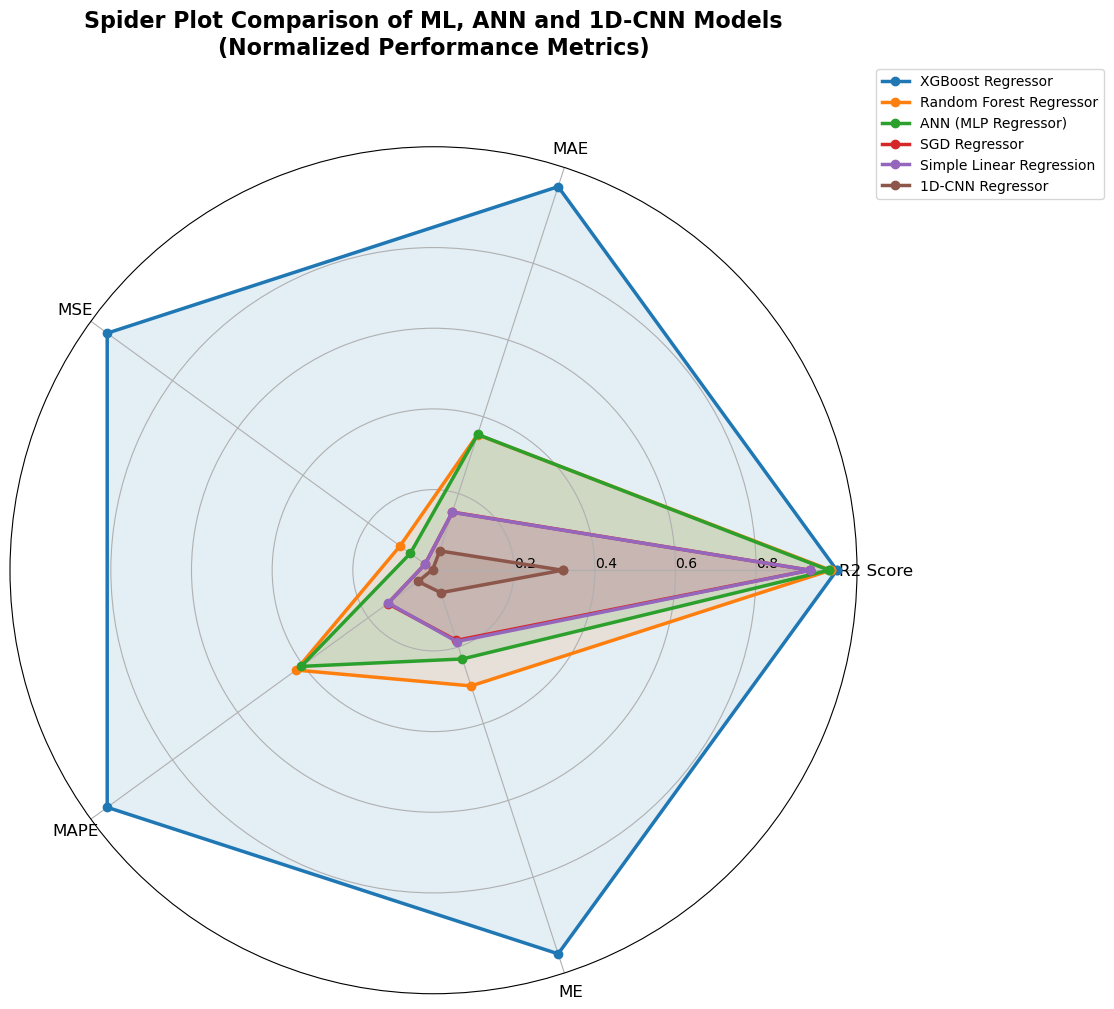

In [33]:
print("GENERATING SPIDER PLOT (All Models)...")

import numpy as np
import matplotlib.pyplot as plt
from math import pi


metrics = ["R2 Score", "MAE", "MSE", "MAPE", "ME"]
categories = metrics
N = len(categories)


angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]   # close loop


norm_df = summary_df.copy()

for col in metrics:
    if col == "R2 Score":
        # Higher is better
        norm_df[col] = norm_df[col] / norm_df[col].max()
    else:
        # Lower is better → invert
        norm_df[col] = norm_df[col].min() / norm_df[col]


plt.figure(figsize=(11, 11))
ax = plt.subplot(111, polar=True)

plt.xticks(angles[:-1], categories, fontsize=12)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], fontsize=10)
plt.ylim(0, 1.05)


for _, row in norm_df.iterrows():
    values = row[metrics].values.tolist()
    values += values[:1]   # close loop
    
    ax.plot(
        angles,
        values,
        linewidth=2.5,
        marker="o",
        label=row["Model"]
    )
    
    ax.fill(
        angles,
        values,
        alpha=0.12
    )


plt.title(
    "Spider Plot Comparison of ML, ANN and 1D-CNN Models\n(Normalized Performance Metrics)",
    fontsize=16,
    fontweight="bold",
    y=1.10
)

plt.legend(
    loc="upper right",
    bbox_to_anchor=(1.30, 1.10),
    fontsize=10
)

plt.show()
